In [3]:
# imports
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [10]:
# Get the data
!wget  https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv
!ls

--2026-09-23 08:19:07--  https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2302 (2.2K) [text/plain]
Saving to: ‘moore.csv’

moore.csv           100%[===================>]   2.25K  --.-KB/s    in 0s      

2026-09-23 08:19:07 (30.7 MB/s) - ‘moore.csv’ saved [2302/2302]

arrhythmia.data  arrhythmia.data.1  auto-mpg.data  moore.csv  sample_data


In [16]:
# Load data

data = pd.read_csv('moore.csv', header=None).to_numpy()

In [18]:
data

array([[       1971,        2300],
       [       1972,        3500],
       [       1973,        2500],
       [       1973,        2500],
       [       1974,        4100],
       [       1974,        4500],
       [       1974,        8000],
       [       1975,        3510],
       [       1976,        5000],
       [       1976,        8500],
       [       1976,        6500],
       [       1978,        9000],
       [       1978,       29000],
       [       1979,       17500],
       [       1979,       29000],
       [       1979,       68000],
       [       1981,       11500],
       [       1982,       55000],
       [       1982,      134000],
       [       1983,       22000],
       [       1984,       63000],
       [       1984,      190000],
       [       1985,      275000],
       [       1985,       25000],
       [       1985,       16000],
       [       1986,      110000],
       [       1986,      375000],
       [       1986,       30000],
       [       1987,

In [20]:
x = data[:,0].reshape(-1,1)
y = data[:,1]

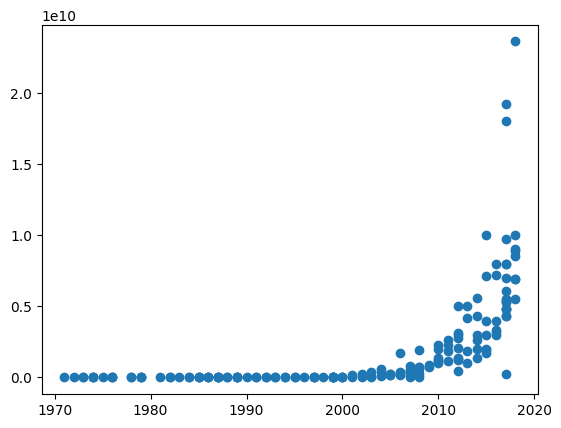

In [21]:
plt.scatter(x,y)

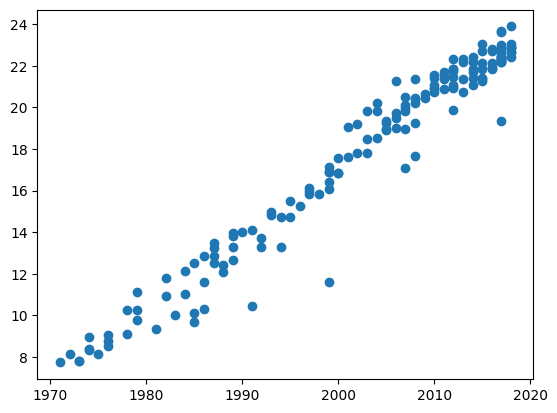

In [23]:
y = np.log(y)
plt.scatter(x,y)

In [25]:
x = x - x.mean()

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

In [34]:
model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.SGD(0.001, 0.9)
)

In [40]:
def lr_scheduler(epoch, lr):
  if epoch >= 50:
    return 0.0001
  else:
    return 0.001

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

In [41]:
r = model.fit(
    x, y,
    epochs=100,
    callbacks=[lr_scheduler]
)


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 432.7022 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 422.6024 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 411.5479 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 253.6566 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 167.9191 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 138.6160 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 83.0735 - learning_rate: 0.0010
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 80.8166 - learning_rate: 0.0010
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 50.9522 - learning_rate: 0.0010
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 35.6884 - learning_rate: 0.0010
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24.0226 - learning_rate: 0.0010
Epoch 12/100


<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

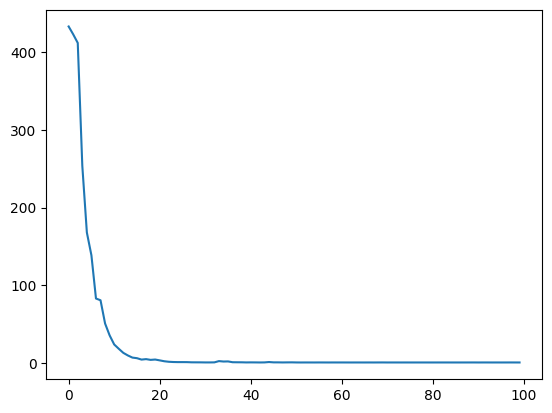

In [42]:
plt.plot(r.history['loss'], label='loss')
plt.legend

In [44]:
model.layers

[<Dense name=dense_1, built=True>]

In [46]:
model.layers[0].get_weights()

[array([[0.3371581]], dtype=float32), array([17.753605], dtype=float32)]

In [48]:
a = model.layers[0].get_weights()[0][0,0]

In [49]:
a

np.float32(0.3371581)

In [52]:
print("time to double:", np.log(2)/a)

time to double: 2.055851994532239


In [57]:
# Re-initialize x and y to ensure correct state after previous errors
x = data[:,0].reshape(-1,1)
y = data[:,1]
y = np.log(y)
x = x - x.mean()

x = x.flatten()
denom = x.dot(x) - x.mean() * x.sum()
a = (x.dot(y) - y.mean() * x.sum()) / denom
b = (y.mean() * x.dot(x) - x.mean() * x.dot(y)) / denom

print(a,b)

0.341682487387313 17.764939393631764
